<a href="https://colab.research.google.com/github/rocioblivingston/Data-Analitycs-Python-1C2026/blob/main/Pre_Entrega_Data_Analitycs_C12026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏗️ Etapa 1: Recopilación y Preparación de Datos**



**1. Carga de Datasets 📥**
Se procede con la importación de las librerías necesarias (**pandas, numpy**) y la carga de los archivos fuente en formato CSV para su transformación en objetos Dataframe.

In [ ]:
# Importa la librería Pandas
import pandas as pd

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 1. Definir las rutas (Paths) de forma coherente
path_clientes  = '/content/drive/MyDrive/Colab Notebooks/Data Analytics 2026/Pre Entrega/DataSets/Copia de clientes.csv'
path_marketing = '/content/drive/MyDrive/Colab Notebooks/Data Analytics 2026/Pre Entrega/DataSets/Copia de marketing.csv'
path_ventas    = '/content/drive/MyDrive/Colab Notebooks/Data Analytics 2026/Pre Entrega/DataSets/Copia de ventas.csv'

Mounted at /content/drive


**DataFrame de Clientes**

In [ ]:
# 2. Cargar los DataFrames
df_clientes  = pd.read_csv(path_clientes)
df_clientes.head()

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65


**DataFrame de Ventas**

In [ ]:
df_ventas  = pd.read_csv(path_ventas)
df_ventas.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


**DataFrame Marketing**

In [ ]:
df_marketing  = pd.read_csv(path_marketing)
df_marketing.head()

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024


##

## **📈 Análisis Exploratorio: Estructura y Dimensiones 📋**

En esta etapa, realizamos una primera aproximación a los conjuntos de datos de **Ventas, Marketing y Clientes**. El objetivo es validar la integridad de la carga desde Google Drive y obtener una visión panorámica de las variables, tipos de datos y la distribución inicial de la información.

In [ ]:
datasets = {
    "Ventas": df_ventas,
    "Marketing": df_marketing,
    "Clientes": df_clientes
}

for nombre, df in datasets.items():
    print(f"{'='*30}")
    print(f"📊 DATASET: {nombre.upper()}")
    print(f"{'='*30}")

    # Introducción a Pandas: Análisis exploratorio inicial
    print("\n🔹 Estructura y Dimensiones")
    print(f"📏 El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")


    print("-" * 40)
    print("\n🔹 Tipos de Datos")
    print(df.dtypes)

    print("-" * 40)
    print("\n🔹 Primeros Registros")
    display(df.head(5))

    print("\n📈 Estadísticas descriptivas")
    print(df.describe(include='number'))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")

    try:
        print(df.describe(include='object'))
    except:
      print("No hay variables categóricas")



    # Calidad de Datos: Identificación de nulos y duplicados
    print("-" * 40)
    print("\n🔹 Diagnóstico de Calidad de Datos")

    # Identificación de nulos
    nulos = df.isnull().sum()
    if nulos.sum() > 0:
        print(f"⚠️ Valores nulos detectados por columna:\n{nulos[nulos > 0]}")
    else:
        print("✅ No se detectaron valores nulos.")
        print("-" * 40)

    print("📌 Porcentaje de nulos por columna %")
    porcentaje_nulos = df.isnull().mean() * 100
    if (porcentaje_nulos > 0).any():
        print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos (0% en todas las columnas)")
    print("-" * 40)

    # Identificar duplicados
    duplicados = df.duplicated().sum()
    print(f"🔁 Cantidad de registros duplicados: {duplicados}")

    print("\n" + "—"*50 + "\n")



📊 DATASET: VENTAS

🔹 Estructura y Dimensiones
📏 El dataset tiene 3035 filas y 6 columnas.
----------------------------------------

🔹 Tipos de Datos
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object
----------------------------------------

🔹 Primeros Registros


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos



📈 Estadísticas descriptivas
          id_venta     cantidad
count  3035.000000  3033.000000
mean   1499.851400     6.496538
std     866.465379     3.457250
min       1.000000     1.000000
25%     748.500000     3.000000
50%    1502.000000     7.000000
75%    2249.500000     9.000000
max    3000.000000    12.000000
----------------------------------------

📈 Estadísticas descriptivas
               producto  precio fecha_venta   categoria
count              3035    3033        3035        3035
unique               30    2590         364           3
top     Lámpara de mesa  $76.32  06/04/2024  Decoración
freq                181       5          24        1015
----------------------------------------

🔹 Diagnóstico de Calidad de Datos
⚠️ Valores nulos detectados por columna:
precio      2
cantidad    2
dtype: int64
📌 Porcentaje de nulos por columna %
precio      0.065898
cantidad    0.065898
dtype: float64
----------------------------------------
🔁 Cantidad de registros duplicados: 35

—

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024



📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
----------------------------------------

📈 Estadísticas descriptivas
               producto canal fecha_inicio   fecha_fin
count                90    90           90          90
unique               30     3           78          78
top     Adorno de pared    TV   25/09/2024  05/05/2024
freq                  3    30            2           3
----------------------------------------

🔹 Diagnóstico de Calidad de Datos
✅ No se detectaron valores nulos.
----------------------------------------
📌 Porcentaje de nulos por columna %
No hay valores nulos (0% en todas las columnas)
----------------------------------------
🔁 Cantidad de registros duplicados: 0

—————————————————————————————————————————

,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65



📈 Estadísticas descriptivas
       id_cliente        edad      ingresos
count  567.000000  567.000000    567.000000
mean   284.000000   37.940035  34668.739012
std    163.823075   10.202885  12974.531446
min      1.000000   20.000000    170.290000
25%    142.500000   30.000000  26015.240000
50%    284.000000   37.000000  35066.830000
75%    425.500000   43.000000  42457.100000
max    567.000000   81.000000  88053.010000
----------------------------------------

📈 Estadísticas descriptivas
             nombre         ciudad
count           567            567
unique          567             12
top     Micah Matis  Mar del Plata
freq              1             63
----------------------------------------

🔹 Diagnóstico de Calidad de Datos
✅ No se detectaron valores nulos.
----------------------------------------
📌 Porcentaje de nulos por columna %
No hay valores nulos (0% en todas las columnas)
----------------------------------------
🔁 Cantidad de registros duplicados: 0

———————————————

***Documentación del Estado Inicial:***

***Ventas:*** Se identificaron registros duplicados que serán eliminados para evitar sesgos en el cálculo de ingresos.

***Clientes/Marketing:*** El dataset se encuentra íntegro en cuanto a valores nulos, permitiendo una integración directa en la **Etapa 2.**




## **🧹 Etapa 2: Preprocesamiento y Limpieza de Datos**

En esta etapa, transformamos los datos crudos en información útil. Corregimos inconsistencias, realizamos cálculos de rentabilidad y segmentamos los productos según su desempeño.

**PREP Clientes**
Ningun tipo de cambio para realizar.


**PREP Ventas**

En esta sección realizamos el saneamiento del dataset de ventas, corrigiendo formatos de moneda, ajustando tipos de datos técnicos y eliminando registros redundantes para asegurar la precisión de los cálculos posteriores.

In [ ]:
# Hacemos una copia para trabajar seguros
df_ventas_pp = df_ventas.copy()

# Renombramos la columna 'precio' a 'precio_unitario'
df_ventas_pp = df_ventas_pp.rename(columns={'precio': 'precio_unitario'})

print("✅ Columna renombrada y copia creada.")
df_ventas_pp.head(1)

✅ Columna renombrada y copia creada.


,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración


**Bloque 2: Limpieza de la columna Precio**
Acá se cambió el símbolo de moneda y transformó el texto en un número real (float) para poder hacer cálculos.

In [ ]:
# Limpieza de la columna precio_unitario
# Forzamos a que sea texto (.astype(str)) para que el .str.replace no falle

df_ventas_pp['precio_unitario'] = df_ventas_pp['precio_unitario'].astype(str).str.replace('$', '', regex=False)

# Ahora sí lo pasamos a float para hacer cálculos
df_ventas_pp['precio_unitario'] = df_ventas_pp['precio_unitario'].astype(float)

print(f"✅ Precio limpiado. Tipo de dato actual: {df_ventas_pp['precio_unitario'].dtype}")
df_ventas_pp.head(1)

✅ Precio limpiado. Tipo de dato actual: float64


,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración


**Bloque 3: Formato de Fecha **
Cambiamos el formato de la fecha para que Python la reconozca como tal y no como un simple texto.

In [ ]:
# Usamos dayfirst=True para que reconozca el formato día/mes/año de Argentina
df_ventas_pp['fecha_venta'] = pd.to_datetime(df_ventas_pp['fecha_venta'], dayfirst=True)

print(f"✅ Tipo de dato de fecha_venta: {df_ventas_pp['fecha_venta'].dtype}")
df_ventas_pp.head(3)

✅ Tipo de dato de fecha_venta: datetime64[ns]


,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración
1,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración
2,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos


**Bloque 4: Nulos y Duplicados**
Este bloque borramos datos duplicados y datos vacios del dataset, eliminando lo que sobra o lo que está incompleto según las acciones y parametros que se dió en el curso

In [ ]:
# Tratamiento de Valores Nulos (eliminamos las filas con nulos en precio o cantidad)
df_ventas_pp = df_ventas_pp.dropna(subset=['precio_unitario', 'cantidad'])

# Eliminación de Duplicados (removemos los 35 registros)
df_ventas_pp = df_ventas_pp.drop_duplicates()

print("✅ Limpieza de nulos y duplicados completada.")
print(f"Total de registros finales: {len(df_ventas_pp)}")

✅ Limpieza de nulos y duplicados completada.
Total de registros finales: 2998


**PREP Marketing**


Solamente se procede a realizar:
* Tipos de datos: convertir (parse) fecha_inicio y fecha_fin a datetime.


In [ ]:
# Volvemos a hacer lo mismo, una copia de seguridad
df_marketing_pp = df_marketing.copy()
df_marketing_pp.head(1)

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024


In [ ]:
# Usamos dayfirst=True para que reconozca el formato día/mes/año de Argentina

df_marketing_pp['fecha_inicio'] = pd.to_datetime(df_marketing_pp['fecha_inicio'], dayfirst=True, format="%d/%m/%Y")
df_marketing_pp['fecha_fin'] = pd.to_datetime(df_marketing_pp['fecha_fin'], dayfirst=True, format="%d/%m/%Y")

print(f"✅ Tipo de dato de fecha_inicio: {df_marketing_pp['fecha_inicio'].dtype}" + " | " +  f"✅ Tipo de dato de fecha_fin: {df_marketing_pp['fecha_fin'].dtype}")
df_marketing_pp.head(2)


✅ Tipo de dato de fecha_inicio: datetime64[ns] | ✅ Tipo de dato de fecha_fin: datetime64[ns]


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13


## **Bloque 1:** Cálculo de Ingresos (Venta Neta)

In [ ]:
# Creamos la columna de ingresos totales por transacción
# Usamos las df ya normalizados
df_ventas_pp["venta_neta"] = df_ventas_pp["precio_unitario"] * df_ventas_pp["cantidad"]

print("✅ Columna 'venta_neta' calculada.")
display(df_ventas_pp[['producto', 'venta_neta']].head(3))

✅ Columna 'venta_neta' calculada.


,producto,venta_neta
0,Cuadro decorativo,349.70
1,Lámpara de mesa,525.50
2,Secadora,293.88


**Bloque 2:** Consolidación por Producto

In [ ]:
# Agrupamos todas las ventas por cada producto
# Renombramos la tabla para que sea más clara (Performance de Productos)
df_performance_prod = df_ventas_pp.groupby("producto", as_index=False)["venta_neta"].sum()

# Lo ordenamos de mayor a menor para identificar rápido a los mejores
df_performance_prod = df_performance_prod.sort_values(by="venta_neta", ascending=False)

print("✅ Resumen de ventas por producto generado.")

✅ Resumen de ventas por producto generado.


**Bloque 3:** Identificación del "Top Performance"

In [ ]:
# Definimos el umbral del 10% superior (Percentil 90)
corte_top = df_performance_prod["venta_neta"].quantile(0.9)

# Filtramos nuestra tabla para quedarnos solo con la elite de productos
df_productos_estrella = df_performance_prod[df_performance_prod["venta_neta"] >= corte_top].copy()

print(f"⭐ Umbral para ser Producto Estrella: ${corte_top:,.2f}")
print(f"📊 Cantidad de productos en el top: {len(df_productos_estrella)}")
display(df_productos_estrella)

⭐ Umbral para ser Producto Estrella: $60,902.87
📊 Cantidad de productos en el top: 3


,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89


In [45]:
# hacemos el groupby por producto y la agregacion por venta_neta (suma)
df_ventas_agg = df_ventas_pp.groupby(["producto"], as_index=False)["venta_neta"].sum()

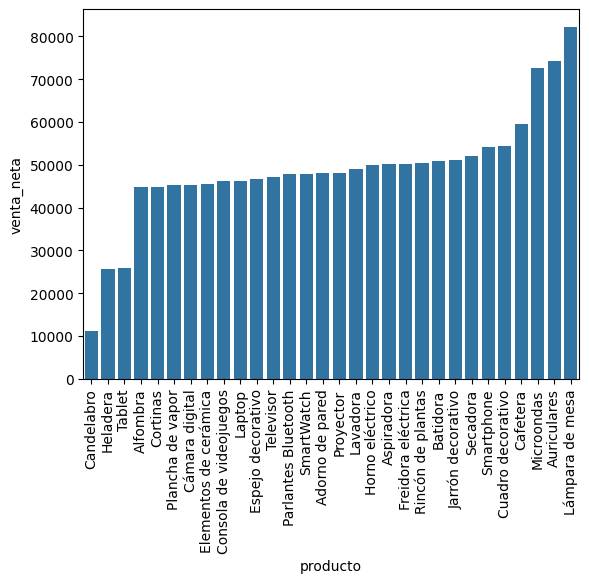

In [47]:
# breve visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
df_ventas_agg = df_ventas_agg.sort_values(by="venta_neta", ascending=True)
sns.barplot(x="producto", y="venta_neta", data=df_ventas_agg)
plt.xticks(rotation=90)
plt.show()

## 🔗 Etapa 3: Consolidación de Inteligencia Comercial
Unificación de métricas de ventas y campañas de marketing para el análisis de correlación y tendencias.


**Bloque 1:** Resumen de Marketing por Producto
Antes de unir las tablas, ordenamos y agrupamos tu set de marketing para saber cuánto se invirtió por cada producto en cada canal.

In [ ]:
# Ordenamos el dataframe de marketing por los campos clave
df_marketing_pp = df_marketing_pp.sort_values(by=["id_campanha", "producto", "canal"])

# Agrupamos para consolidar los costos
df_marketing_resumen = df_marketing_pp.groupby(["id_campanha", "producto", "canal"], as_index=False)["costo"].sum()

print("✅ Resumen de inversión por producto preparado.")
display(df_marketing_resumen.head(3))

✅ Resumen de inversión por producto preparado.


,id_campanha,producto,canal,costo
0,1,Cuadro decorativo,RRSS,5.27
1,2,Lámpara de mesa,RRSS,5.88
2,3,Secadora,RRSS,5.10


**Bloque 2**: El Cruce de Datos (Merge)
Acá es donde se unen ambas tablas. Usamos df_ventas_pp (tu tabla de ventas limpia) y la cruzamos con el resumen de marketing que acabamos de hacer.

In [ ]:
#  Calculamos la venta total antes de unir (para control)
total_venta_antes = df_ventas_pp["venta_neta"].sum()

#  Hacemos la unión (merge) por la columna "producto"
# 'df_consolidado' será tu nueva tabla maestra
df_consolidado = pd.merge(df_ventas_pp, df_marketing_resumen, on="producto", how="left")

# Calculamos la venta total después de unir
total_venta_despues = df_consolidado["venta_neta"].sum()

print(f"💰 Venta original: ${total_venta_antes:,.2f}")
print(f"💰 Venta tras la unión: ${total_venta_despues:,.2f}")

💰 Venta original: $1,467,093.52
💰 Venta tras la unión: $4,401,280.56


**Bloque 3:** Filtrado de Redes Sociales (RRSS)
Como el profe mencionó en su ejemplo, una forma de evitar el "ruido" de tantas campañas es enfocarse en los canales más importantes: las **redes sociales.**

In [ ]:
# Creamos una lista con los canales que consideramos RRSS
canales_rrss = ["RRSS"]

# Filtramos el dataframe consolidado solo para estos canales
df_rrss = df_consolidado[df_consolidado["canal"].isin(canales_rrss)].copy()

print(f"✅ Se filtraron los datos para RRSS. Registros: {len(df_rrss)}")
df_rrss.head(3)

✅ Se filtraron los datos para RRSS. Registros: 2998


,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.70,1,RRSS,5.27
3,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.50,2,RRSS,5.88
6,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10


**🕵️ Bloque 4: Validación de Ventas en Campaña**
No todas las ventas de un producto son gracias al marketing; algunas ocurren fuera de las fechas de la campaña. Vamos a crear una columna "inteligente" que nos diga si la venta coincide con el período publicitario.

In [ ]:
# 1. Creamos la columna "en_campanha" (True/False)
# Verificamos si la fecha de venta está entre el inicio y el fin de la publicidad
df_rrss["en_campanha"] = (
    (df_rrss["fecha_venta"] >= df_marketing_pp["fecha_inicio"].min()) &
    (df_rrss["fecha_venta"] <= df_marketing_pp["fecha_fin"].max())
)

# 2. Nos quedamos solo con las ventas que SÍ fueron durante una campaña activa
df_ventas_marketing_activas = df_rrss[df_rrss["en_campanha"] == True].copy()

print(f"🎯 Ventas influenciadas por campañas de RRSS: {len(df_ventas_marketing_activas)}")
display(df_ventas_marketing_activas.head(3))

🎯 Ventas influenciadas por campañas de RRSS: 2312


,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,en_campanha
2058,197,Elementos de cerámica,89.17,4.0,2024-03-20,Decoración,356.68,22,RRSS,5.44,True
2061,206,Cortinas,73.65,2.0,2024-03-20,Decoración,147.30,13,RRSS,5.22,True
2064,234,Jarrón decorativo,112.40,9.0,2024-03-20,Decoración,1011.60,15,RRSS,4.65,True


📊 **Bloque Final**: Terminando el desarrollo de análisis...la conclusión

In [ ]:
# Agregamos por canal (RRSS) la suma de ventas y la suma de costos
resumen_final = df_ventas_marketing_activas.groupby("canal").agg(
    venta_total = ("venta_neta", "sum"),
    inversion_total = ("costo", "sum")
).reset_index()

# Calculamos el ROI (Retorno de Inversión) simplificado
resumen_final["ganancia_neta"] = resumen_final["venta_total"] - resumen_final["inversion_total"]

print("🏆 Informe Final de Rendimiento RRSS:")
display(resumen_final)

🏆 Informe Final de Rendimiento RRSS:


,canal,venta_total,inversion_total,ganancia_neta
0,RRSS,1131193.81,11760.15,1119433.66
